<h1>ML basics</h1>
Deep learning works by performing large‑scale numerical computation on tensor (scalars, vectors, matrices and higher‑dimensional arrays). Getting comfortable with shape, rank, dtype and a few core operations (indexing, broadcasting, matmul, reductions) prevents most bugs when building models.

Import TensorFlow (GPU/CPU numerical engine + deep learning library) and NumPy (general numerical Python library). Print the TF version. Some behaviors (e.g., default dtypes) can vary across versions.

In [1]:
import tensorflow as tf
import numpy as np

print("TF:", tf.__version__)

TF: 2.20.0


Rank = number of axes (dimensions).  
scalar has rank 0 (shape=()) > a single number;  
vector rank 1 (shape=(3,));  
matrix rank 2 (shape=(2,2));  
tensor rank 3 (shape=(2,2,1)).  
Shape = size along each axis (batch, height, width...).

  
Your models understand only numbers and shapes. 

In [2]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank-0
vector = tf.constant([10, 20, 30]) # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor  = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3 (2x2x1)
test = tf.constant([[[[32, 64, 64, 3]]]]) #Number of bracket layers = number of dimensions use for tf.constant

print(scalar.shape, vector.shape, matrix.shape, tensor.shape, test.shape)
print(scalar.ndim, vector.ndim, matrix.ndim, tensor.ndim, test.ndim)

() (3,) (2, 2) (2, 2, 1) (1, 1, 1, 4)
0 1 2 3 4


<i>Extra task:</i><br>
What’s the rank/shape of an RGB image with 32 images 64×64 pixels?



- tf.zeros
    - transmit shape, not data
- tf.constant
    - transmit data

In [3]:
#tf.zeros: This creates a Tensor where all the elements inside are equal to 0. 
#In image processing, the value 0 usually represents absolute black.
img_batch = tf.zeros([32, 64, 64, 3])  # 32 images, 64×64, RGB, A batch of 32 completely black images.
print(img_batch.shape, img_batch.ndim) # (32, 64, 64, 3), rank=4

test1 = tf.zeros([1,2,3,4,5,6])
print(test1.shape, test1.ndim)

(32, 64, 64, 3) 4
(1, 2, 3, 4, 5, 6) 6


tf.zeros([32, 64, 64, 3]) creates a new tensor of the given shape filled with zeros. In the context of images 0 means no intensity > a completely black pixel.<br><br>
So img_batch is a batch of 32 solid‑black images, each 64×64 with 3 color channels.

In [4]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4]) # float32 default
y = tf.constant([7, 10]) # int32 default
x16 = tf.cast(x, tf.float16) # reduced precision floats

y32 = tf.cast(y, tf.float32) # cast ints → floats

print(x.dtype)
print(x16.dtype)

<dtype: 'float32'>
<dtype: 'float16'>


A dtype (data type) tells TensorFlow what kind of numbers a tensor stores, e.g., float32, float16, int32, or bool. It’s one of the three core properties of a tensor alongside shape and rank. The dtype you choose affects memory use and numerical precision, so it has practical consequences for speed and stability.
<br><br>
Casting (Data type conversion) changes dtype without changing shape. float16 halves memory but reduces precision. Good for speed on certain GPUs.

In [5]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7], [3, 4]])
last_col = rank2[:, -1] # column slice
expanded = tf.expand_dims(rank2, -1) # add channel-like axis
squeezed = tf.squeeze(expanded, axis=-1)

print(last_col)
print (expanded)

tf.Tensor([7 4], shape=(2,), dtype=int32)
tf.Tensor(
[[[10]
  [ 7]]

 [[ 3]
  [ 4]]], shape=(2, 2, 1), dtype=int32)


last_col = rank2[:, -1]
- ":" mean picks all rows. 
- -1 selects the last column. last_col has shape (2,). So it will get [7,4], and it a vector

<b>Reshaping:</b>

- expand_dims(..., -1) adds a new axis at the end: (2,2) > (2,2,1).adding a new dimension<br>
- squeeze(..., axis=-1) removes a size‑1 axis: back to (2,2).

In [6]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.], [3., 4.]])
print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


Basic ops: +, * operate per position. This is different from matrix multiplication (tf.matmul).

Matmul rule: For A @ B, the inner dimensions must match: (m×n) @ (n×p) -> (m×p). So you transpose Y (from (3×2) to (2×3)) to make 2 match 2.<br><br>
Matrix multiplication is central to neural networks. 

In [7]:
# 5) Matrix multiplication rules (inner dims match)
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # (3x2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # (3x2)
XtY = tf.matmul(X, tf.transpose(Y))     # (3x2) @ (2x3) -> (3x3)

In [8]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(), #TensorFlow requires the data type to be a floating-point number in order to calculate the average.
      "sum:", tf.reduce_sum(E).numpy())

print (E)

min: 16 max: 99 mean: 65.7 sum: 657
tf.Tensor([97 52 92 67 17 75 85 99 16 57], shape=(10,), dtype=int64)


<b>Extra example  of why should we change int to float:</b>

In [9]:

M = tf.constant([[1., 2.], [3., 4.]])  # (2,2)
print(tf.reduce_mean(M, axis=0).numpy())  # column means -> [2., 3.]
print(tf.reduce_mean(M, axis=1).numpy())  # row means    -> [1.5, 3.5]

[2. 3.]
[1.5 3.5]


- Rule: axis=0 is the vertical axis (row). When you select axis=0, TensorFlow will "force" the rows together. Calculation: * Column 1: $(1.0 + 3.0) / 2 = \mathbf{2.0}$ Column 2: $(2.0 + 4.0) / 2 = \mathbf{3.0}$ Result: [2., 3.]
- axis=1 is the horizontal axis (column).

In [10]:
# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh  = tf.one_hot(idx, depth=4)
print (oh)
#depth=4 means you're telling TensorFlow that there are a total of 4 labels. If you set depth=5,
# the result will have an additional column of zeros at the end.

tf.Tensor(
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]], shape=(4, 4), dtype=float32)


Each integer label becomes a vector of length depth; only the index position is 1, others 0. Example:<br>
0 -> [1,0,0,0]<br>
1 -> [0,1,0,0]

In [11]:
labels = tf.constant([2, 0, 1])
print(tf.one_hot(labels, depth=3).numpy())

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


You can convert NumPy arrays <-> TensorFlow tensors easily.

In [12]:

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t   = tf.constant(arr) # NumPy -> Tensor
back_to_np = t.numpy() # Tensor -> NumPy

print("OK")

OK


<h2>Regression model</h2><br>
The standard Keras workflow: Create -> Compile -> Fit -> Evaluate -> Predict -> Visualize.<br><br>
Separate train/test to measure generalization instead of memorization.

We use Matplotlib for visualization. 

In [13]:
#import tensorflow as tf
#import numpy as np
import matplotlib.pyplot as plt

In [14]:
# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20., -18., ..., 20.]
y = X + 10

<img src="Screenshot_function.png" alt="y=X + 10">

Split material, first 20 points for training, remaining for testing.<br><br>
Split to evaluate on data not seen during training to estimate generalization (how well the learned rule applies to new inputs).

In [15]:
# Train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test,  y_test  = X[20:], y[20:]

Read more: <a href="https://keras.io/guides/sequential_model/">Sequential model</a><br><br>
A Sequential model is Keras’s model type for a single straight pipeline: one input > layers in order > one output. It’s ideal whenever your architecture is a plain stack (no branches/merges). This includes simple regression or classification on a single input vector and single input image pipelines. 

If the task has multiple inputs (e.g., image + numeric features) or needs branching/merging, switch to the Functional API. With Functional, you can build separate layer branches, an MLP (Dense) branch for numeric features and a CNN (Conv2D/MaxPool2D) branch for images. Then merge their features (e.g., Concatenate) and finish with a linear Dense output for regression (e.g. house price depending on size + photo).

A layer takes one or more tensors in and outputs one or more tensors after applying a computation (its call method). It also holds state (weights) that training updates. Layers are the basic building blocks you stack to form models. 

API in this case means a set of classes and methods you call to build neural networks.
<br>

Why is shape=(1,)?: <br>
- Remember example $X = [-20, -18, ...]$? Each time the machine learns, it picks one number from $X$ to process. <br>

tf.keras.layers.Dense(1)
- Why 1?: Because your problem is Regression – predicting a specific number ($y$). After calculation, this class will output exactly one result. The secret formula inside: When you declare this class, TensorFlow will automatically generate a calculation: y = W * X + b.
Initially, $W$ and $b$ will be random numbers. The training process's task is to find $W=1$ and $b=10$ to match your formula $y = X + 10$.

In [16]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)  # linear output for regression
])

A loss function turns your model’s mistakes into one number so the training loop knows how “wrong” the model is right now. Keras needs this number to decide how to adjust the weights on the next step. Without a loss, the model has no target to improve.
Why we need it (practically):

Gives the optimizer a target. During model.fit, Keras computes the loss on each batch and the optimizer uses it to nudge the weights to make that number smaller next time.

Enables training with one line. model.compile(loss=..., optimizer=..., metrics=...) wires everything so Keras can run the built‑in training loop. 
Lets you compare and monitor. You can watch training vs. validation loss to see if you’re improving, plateauing, or overfitting.

In [17]:
# 2) COMPILE
model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

model.fit(...) runs Keras’s built‑in training loop. On each epoch, the model makes predictions on batches of X_train, computes the loss against y_train, and the optimizer updates the weights to try to reduce that loss next time. The call returns a History object that contains per‑epoch logs (e.g., loss) in history.history.
epochs=200: “Try the whole dataset 200 times.” More epochs can help if the model hasn’t converged yet—but watch validation to avoid overfitting. 
<br><br>
verbose=0: hides per‑epoch printing. Use verbose=1 to show an epoch‑by‑epoch progress line, or verbose=2 to show one summary line per epoch.
<br><br>
If you want training to stop automatically when improvement stalls, add callbacks like EarlyStopping (optionally restoring the best weights). This is standard practice in Keras. 

In [18]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - loss: 10.9465 - mae: 10.9465
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.7465 - mae: 10.7465
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.6143 - mae: 10.6143
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.5287 - mae: 10.5287
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.5087 - mae: 10.5087
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 10.4887 - mae: 10.4887
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.4687 - mae: 10.4687
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.4487 - mae: 10.4487
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 10.4287 - mae: 10.4287
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 10.4087 - mae: 10.4087
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.3887 - mae: 10.3887
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 10.3687 - mae: 10.3687
Epoch 13/200
1/1 ━━━━━━━

model.evaluate(...) runs the model on unseen test data and computes the loss and any metrics you set in compile. This measures generalization, not training progress.
<br><br> 
For a model compiled with a single metric (metrics=["mae"]), evaluate returns two numbers: [loss, metric]. Because here the loss is also "mae", you’ll typically see very similar values for loss and mae. Printing “Test MAE:” gives an accuracy number in target units.
<br><br>
Performance should be judged on data not used during training. This is how we check the model learned the rule (here, y = x + 10) rather than memorizing specific points.

In [19]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 15.982648849487305


model.predict(...): produces outputs for new inputs without changing weights. We squeeze to make the array 1‑D for plotting.
<br><br>
Why the plot: Numbers summarize; plots explain. Showing true test points (green) and predictions (red) over the same X_test makes it visually clear whether the learned line matches the underlying rule. This aligns with the teaching guidance in your material—visual inspection reveals bias and systematic mismatches better than a single average number.
<br><br>
What to expect here: If training went well, the red predicted points should lie close to the green test points along a line with slope = 1 and intercept = 10 (the model has learned y = x + 10). Your evaluate step’s Test MAE should be small, and the scatter should show tight overlap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


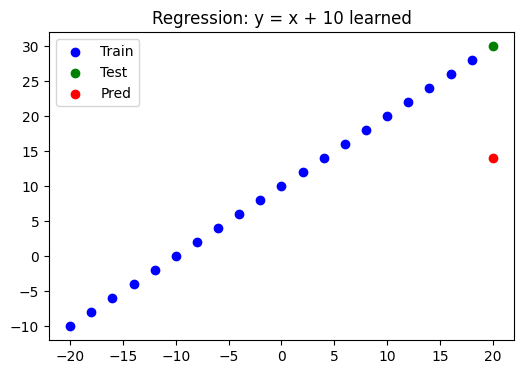

In [20]:
# Predict and visualize
y_pred = model.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()

HOMEWORK: Fix the regression model

độ dài X: 90
độ dài X_train: 72
Test MAE: 0.003306918777525425
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


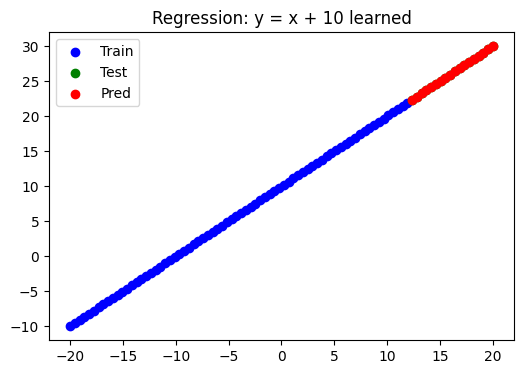

In [ ]:
# Synthetic linear data
# X = np.arange(-20, 21, 1, dtype=np.float32)  # [-20., -18., ..., 20.]
X = np.linspace(-20, 20, 90, dtype=np.float32)
y = X + 10
# Train/test split (simple)
# X_train, y_train = X[:20], y[:20]
# X_test,  y_test  = X[20:], y[20:]
split_index = int(0.8 * len(X)) 
X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test = X[split_index:], y[split_index:]
print (f"độ dài X: {len(X)}")
print (f"độ dài X_train: {split_index}")


# 1) CREATE
model2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    # tf.keras.layers.Dense(10, activation='relu'),
    # tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dense(1)  # linear output for regression
])
# 2) COMPILE
model2.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["mae"]
)

# 3) FIT
history = model2.fit(X_train, y_train, epochs=500, verbose=0)

# Evaluate
loss, mae = model2.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)

#The evaluate command (Taking an exam): In this step, the model takes X_test as input, makes a prediction, and then compares it with y_test to report the margin of error (MAE) to you.
# Most importantly: after knowing how wrong it is, the model does not update the weights. 
# It just stands there and receives the score and that's it.

# Predict and visualize
y_pred = model2.predict(X_test).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test,  y_test,  c='g', label='Test')
plt.scatter(X_test,  y_pred,  c='r', label='Pred')
plt.legend(); plt.title("Regression: y = x + 10 learned")
plt.show()


<h1>Classification</h1>

This is a Python code  that uses the TensorFlow/Keras library to build a model neural network to solve the binary classification problem (binary categorization) based on linear data analysis properties. <br>

Specifically, the model's task is: "Look at the coordinates of a point on a plane and guess how many percent whether that point belongs to group A or group B."

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

- matplotlib.pyplot: Used to plot graphs and visualize results.
- make_circles: A function from Scikit-learn that creates simulated data in the shape of two overlapping circles. This is non-linear data (it cannot be divided by a straight line).

- train_test_split: Used to split data into two parts: one part for training and one part for testing accuracy.

In [ ]:
# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

Create 1000 simulated data points on a coordinate plane (x, y). <br>
The make_circles function returns a tuple (a pair) of two separate data arrays: 
- The first array (X): Contains the coordinates $(x, y)$. 
- The second array (y): Contains the labels $0$ or $1$.
    - y = 0: Point on the outermost circle.
    - y = 1: Point on the innermost circle. 

random_state: Run 1, run 10, or run 100: The coordinates in X and the labels in Y will remain in their exact positions, without changing.

In [ ]:
# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") #There is only one neuron because we only need one answer: "Is this class 0 or class 1?".Give the final answer in the form of probabilities.
])

layers.Input(shape=(2,)): Why the number 2? Because each of our data points (variable X) has 2 coordinates, $(x, y)$. It's like a scanner only accepts input that is a pair of numbers.

Without ReLU, the model can only understand straight lines (linear).

Sigmoid (For Binary Classification - 1 output)

In [ ]:
# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

1. loss="binary_crossentropy" (Error Measure)

This is the most important part. Loss is a number that indicates how "bad" the model is.

Why use Binary Crossentropy? This is a specialized mathematical function for binary classification problems (only 0 and 1 classes).

How it works: It compares the probability given by the sigmoid function (e.g., 0.8) with the actual answer y (e.g., 1.0). If the model guesses 0.8 and the answer is 1.0, the loss will be small. If the model guesses 0.1 and the answer is 1.0, the loss will be very large.

Goal: During the learning process, the model will try to make this loss number as small as possible.

2. Adam : Knowing how to flexibly adjust the weights within neurons to reduce loss as quickly as possible.

3. metrics=["accuracy"] (Score)

Task: This is just something for us (humans) to read and understand.

While computers look at loss (complex decimal numbers) to learn, we look at Accuracy to know how correctly the model predicted %.

Example: accuracy: 0.995 means the model correctly predicted 99.5% of the data points.

In [ ]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

In [ ]:
# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - accuracy: 0.5188 - loss: 0.6893 
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.6500 - loss: 0.6656
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - accuracy: 0.7212 - loss: 0.6207
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step - accuracy: 0.8512 - loss: 0.5224
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.9688 - loss: 0.3771
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - accuracy: 0.9775 - loss: 0.2463
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 874us/step - accuracy: 0.9962 - loss: 0.1465
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - accuracy: 1.0000 - loss: 0.0889
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 838us/step - accuracy: 0.9987 - loss: 0.0632
Epoch 10/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - accuracy: 0.9987 - loss: 0.0460
Epoch 11/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 1.0000 - loss: 0.0377
Epoch 12/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/ste

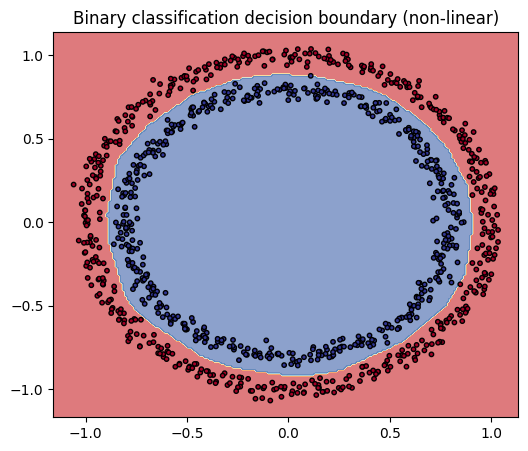

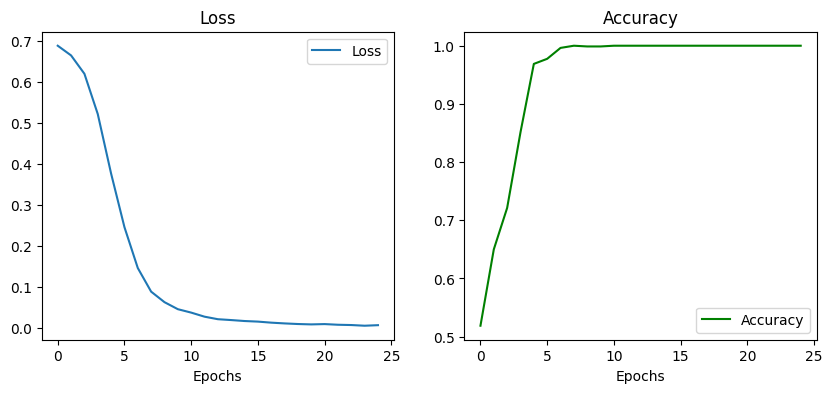

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") #Give the final answer in the form of probabilities.
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=1)

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=10)
plt.title("Binary classification decision boundary (non-linear)")
plt.show()

import pandas as pd

# change history data into DataFrame for drawing.
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(10, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history_df['loss'], label='Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.legend()

#  Accuracy 
plt.subplot(1, 2, 2)
plt.plot(history_df['accuracy'], label='Accuracy', color='green')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.show()


Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5325 - loss: 0.6957 - val_accuracy: 0.6250 - val_loss: 0.6795
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5875 - loss: 0.6734 - val_accuracy: 0.5300 - val_loss: 0.6628
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6850 - loss: 0.6416 - val_accuracy: 0.6550 - val_loss: 0.6319
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8012 - loss: 0.5818 - val_accuracy: 0.8800 - val_loss: 0.5498
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9038 - loss: 0.4640 - val_accuracy: 0.8800 - val_loss: 0.4257
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.3066 - val_accuracy: 0.9750 - val_loss: 0.2613
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.1724 - val_accuracy: 0.9650 - val_loss: 0.1866
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9875 - loss: 0.1166 - val_accuracy: 0.9850 - val_loss:

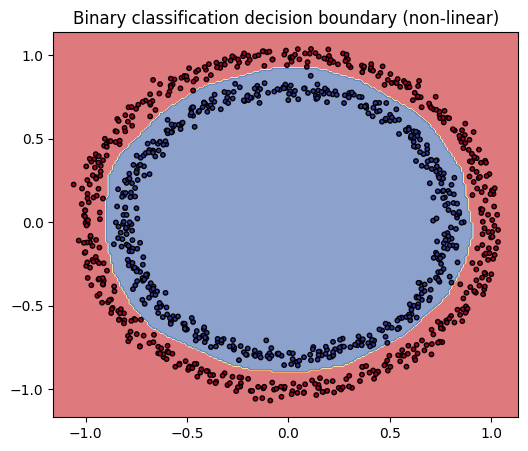

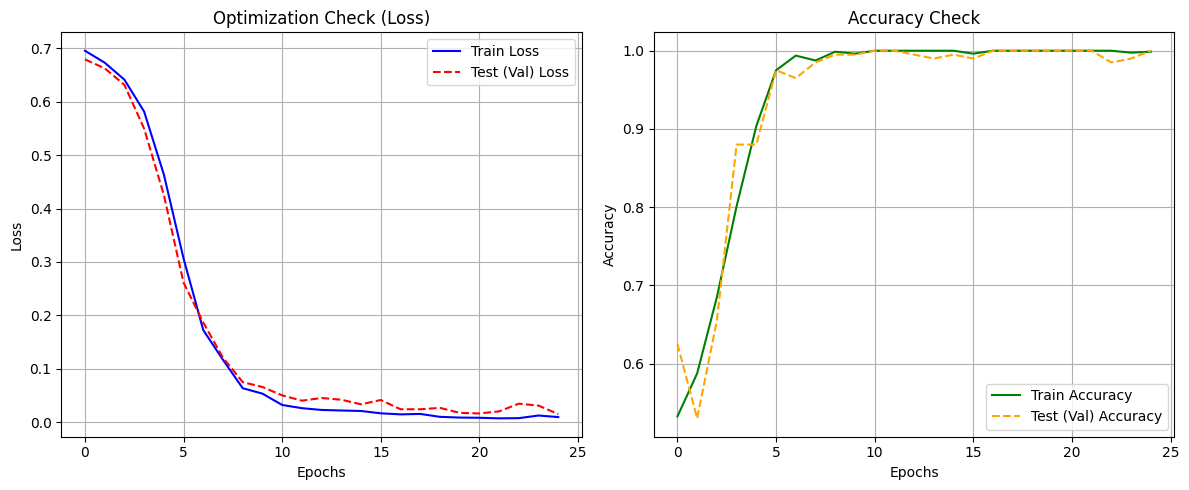

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Non-linear separable data
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 1) CREATE (use non-linear activations + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") #Give the final answer in the form of probabilities.
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=1, validation_data=(X_test, y_test))

# Evaluate
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Visualize decision boundary
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
                     np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', s=10)
plt.title("Binary classification decision boundary (non-linear)")
plt.show()

#Check Optimization vs Accuracy
def plot_learning_curves(history):
    history_df = pd.DataFrame(history.history)
    
    plt.figure(figsize=(12, 5))

    #loss
    plt.subplot(1, 2, 1)
    plt.plot(history_df['loss'], label='Train Loss', color='blue')
    plt.plot(history_df['val_loss'], label='Test (Val) Loss', color='red', linestyle='--')
    plt.title('Optimization Check (Loss)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history_df['accuracy'], label='Train Accuracy', color='green')
    plt.plot(history_df['val_accuracy'], label='Test (Val) Accuracy', color='orange', linestyle='--')
    plt.title('Accuracy Check')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Gọi hàm để xem kết quả "Check"
plot_learning_curves(history)


# Mnist Fashion

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

1. Splitting Train/Test Data
The `tf.keras.datasets.fashion_mnist.load_data()` function is a built-in utility. When I call it, TensorFlow automatically loads a pre-formatted archive file and returns two tuple pairs:

One pair for training (x_train, y_train).

One pair for testing (x_test, y_test).

In practice, with your own data (e.g., photos from your phone), you would have to split it yourself using libraries like scikit-learn (the `train_test_split` function). But with benchmark datasets like Fashion-MNIST, Google has already done this step for user convenience.

Test accuracy: 0.8766999840736389
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


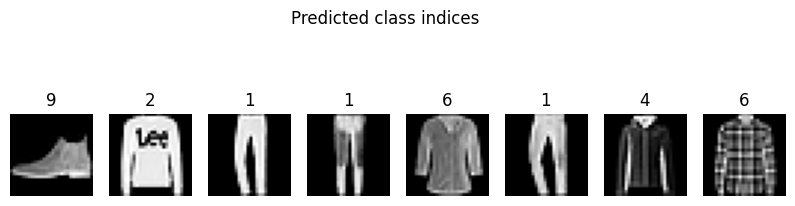

In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
#If we set it to 255, the matrix multiplication calculations inside the model will produce huge numbers, making it difficult for the model to converge. 
# Setting it to 0, 1 makes the internal math smoother.

# 1) CREATE (flatten → Dense ReLU → Dense softmax)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

# 2) COMPILE
model.compile(
    loss="sparse_categorical_crossentropy",  # labels are ints, not one-hot, if one-hot, we use: categorical_crossentropy
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=10, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# Show a few preds
preds = model.predict(x_test[:8]).argmax(axis=1)
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("Predicted class indices"); plt.show()


This code is an evolution from the previous one. Instead of classifying 10 types of clothing using a basic neural network (Dense), using a Convolutional Neural Network (CNN) to solve the binary classification problem (selecting only 2 types: Sneakers and Ankle Boots).

0 (Sneaker) or 1 (Ankle Boot).

In this code, the output is a single number. For example, if the result returned is 0.85, it means that 85% of the model is Ankle Boot.

In [ ]:
# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])


1. The Image Capture Process (Conv2D): When the Conv2D(16, 3) layer scans the $28 \times 28$ image, it doesn't just create a new image. It uses 16 different filters. Each filter is "specialized": some find horizontal lines, some find the curve of the heel, some find eyelets. Result: From one original image, after the first layer you will have 16 "feature maps". 

2. The Shrinking Process (MaxPool2D): As you said, it reduces the size by half. The $28 \times 28$ image after going through Conv (with a 3x3 kernel) will be about $26 \times 26$. Through MaxPool2D, it is "compressed" down to $13 \times 13$. Note: It compresses but still keeps the number of maps the same. So we have 16 small images $13 \times 13$.

3. Repeat the process. Go to the next Conv2D(32, 3) layer: It scans those 16 images again and combines them to create 32 new, even smaller images (about $11 \times 11$). Through MaxPool2D again, they are only about $5 \times 5$. 

4. Flatten and Connect This is a very intuitive description you gave. After all the steps above, the machine is holding 32 images, each extremely small ($5 \times 5$ pixels). The Flatten() command will take $32 \times 5 \times 5 = 800$ of these numbers and arrange them into a single long row (800 elements). This long row is the highest-level "summary" of the shoe's features. 

5. The final result (Dense & Output) 800 numbers are put into the Dense class(64) (like a judging panel of 64 judges). These judges will discuss with each other: "Based on those 800 characteristics, is this a Sneaker or an Ankle Boot?" Finally, all opinions are combined into a single number in the Dense class(1) using the Sigmoid function: If the number is 0.95 $\rightarrow$ "It's 95% certain it's an Ankle Boot!" If the number is 0.12 $\rightarrow$ "No, this is a Sneaker (because it's closer to 0)."

In [ ]:
# 3) FIT
history = model.fit(x_train, y_train, epochs=20, validation_split=0.1, verbose=0)


If validation_split=0.1, the machine will retrieve the test questions from the Train set (x_train, y_train), and will not touch the Test set.

The Train has 10,000 images. The machine will automatically crop out the last 10% (1,000 images) as the "Validation set" (practice test set).

Test accuracy: 0.9739999771118164


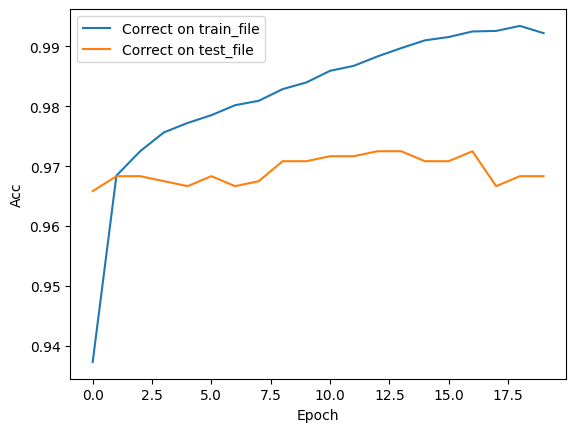

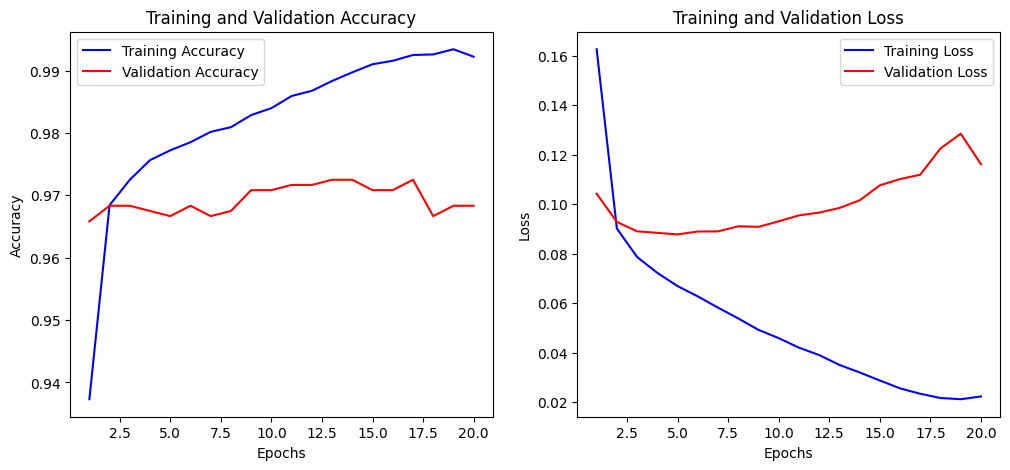

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9, else 0 (7 is 0)
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(x_train, y_train, epochs=20, validation_split=0.1, verbose=0)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

plt.plot(history.history['accuracy'], label='Correct on train_file')
plt.plot(history.history['val_accuracy'], label='Correct on test_file')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend()
plt.show()

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 1.Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2.Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

#
plot_history(history)


fix: add dropout, and use stop_early

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"), 
    tf.keras.layers.Dropout(0.5), # Randomly shut down 50% of neurons each learning cycle
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,          # if val_loss does not decrease after 3 epoch, then stop.
    restore_best_weights=True
)

In the Loss chart, the blue line (Train) always goes down, but the red line (Validation), after a while of going down, starts to rise again. The point where the red line begins to rise is when the model starts "learning by imitation".

Early Stopping will monitor this red line. If after a certain number of iterations (Epochs) the red line doesn't fall any further, it will automatically stop the model.fit() command even if it hasn't completed the set number of Epochs (for example, you set 100 Epochs, but at Epoch 15 it detects something is wrong and stops).

Epoch 1/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9264 - loss: 0.1907 - val_accuracy: 0.9633 - val_loss: 0.1101
Epoch 2/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9625 - loss: 0.1075 - val_accuracy: 0.9633 - val_loss: 0.0910
Epoch 3/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9685 - loss: 0.0891 - val_accuracy: 0.9683 - val_loss: 0.0858
Epoch 4/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9718 - loss: 0.0837 - val_accuracy: 0.9667 - val_loss: 0.0897
Epoch 5/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9721 - loss: 0.0788 - val_accuracy: 0.9650 - val_loss: 0.0922
Epoch 6/20
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9744 - loss: 0.0737 - val_accuracy: 0.9633 - val_loss: 0.1000
Test accuracy: 0.9695000052452087


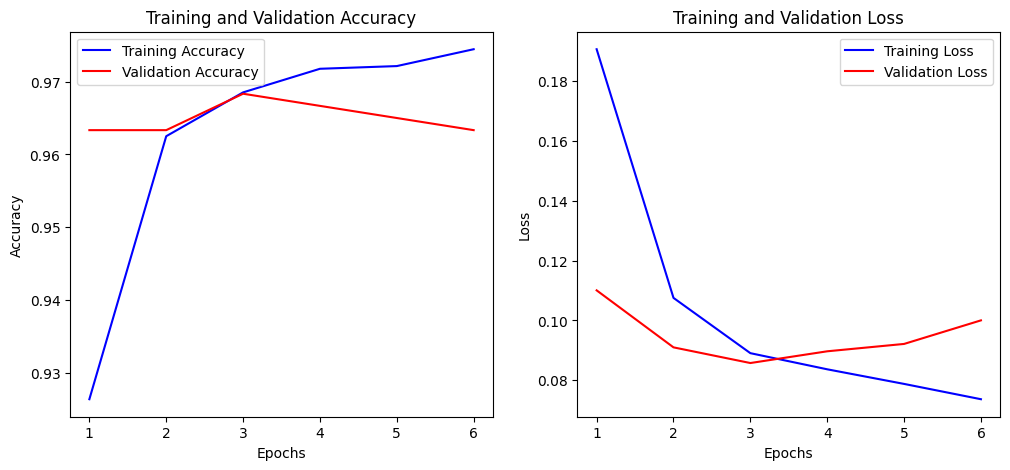

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 168,389 (657.77 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 112,260 (438.52 KB)

In [28]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use Fashion-MNIST but map 2 classes to a binary task (e.g., class 9=Ankle boot vs 7=Sneaker)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Keep only classes 7 and 9
train_mask = np.isin(y_train, [7, 9])
test_mask  = np.isin(y_test,  [7, 9])

x_train = x_train[train_mask][..., None]/255.0
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9, else 0 (7 is 0)
x_test  = x_test[test_mask][..., None]/255.0
y_test  = (y_test[test_mask] == 9).astype(np.float32)

# 1) CREATE (small CNN)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"), # Giảm số lượng neuron
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])



# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

# 3) FIT
# dèifine Early Stopping before Fit
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,          # if val_loss does not decrease after 3 epoch, then stop.
    restore_best_weights=True
)
history = model.fit(x_train, y_train, epochs=20, validation_split=0.1, verbose=1, callbacks=[early_stopping])

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

# plt.plot(history.history['accuracy'], label='Correct on train_file')
# plt.plot(history.history['val_accuracy'], label='Correct on test_file')
# plt.xlabel('Epoch')
# plt.ylabel('Acc')
# plt.legend()
# plt.show()

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 1.Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2.Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# call the func, after run model.fit()
plot_history(history)

model.summary()


1. Explanation of the Layer columns: 
    - Layer (type): Name and type of layer (Conv2D, MaxPooling, Dense...). 
    - Output Shape: Data size after passing through that layer. 
        - None: Represents Batch size (number of images fed in each pass). It is set to None because the model can accept any number of images (1, 32, or 100). 
        - Example (None, 26, 26, 6): This means that after this layer, I have 6 images (due to using 6 filters) with a size of 26 times 26. 
    - Param # (Parameters): The total number of "variables" that the machine must learn in that layer. The more parameters, the heavier the machine and the more data it needs to learn.

2. Analyzing the Key Parameters Below
- Total params (168,389): The total of all variables in the network. Here, your model occupies approximately 657 KB — extremely lightweight, capable of running smoothly even on older phones.
- Trainable params (56129): These are the numbers that the machine actually adjusts during the training (fit).
- Non-trainable params (0): Variables that are "locked" and not allowed for machine learning (often occurs when you reuse a pre-existing Google/Oxford model and only borrow their brain).
- Optimizer params (112,260): These are auxiliary variables that the Adam algorithm creates to support the optimization process (making learning faster and smoother).

Accuracy 0.97: "The model solved 97 out of 100 problems correctly." (Achievement measure)

Loss 0.10: "The average deviation between the model's thinking and the correct answer is 0.10." (Improvement measure)

# Working with color (RGB) images and CIFAR-10 datasets

In [ ]:
# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

CIFAR-10: This is a dataset of real-world objects (airplanes, cars, birds, cats, etc.). 

Size: Images are 32 × 32 × 3. The number 3 at the end represents the three color channels: Red, Green, and Blue.

In [ ]:
# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

Class filtering: only keep the first 3 classes (0: Airplane, 1: Car, 2: Bird). This is a Multi-class classification.

What is the .flatten() command used for?

- Depending on where you use it, it has two main purposes:

 - A. In data masking
    - The default CIFAR-10 dataset returns the y_train label as a 2D array: [[6], [9], [0], ...].

    - When perform a comparison y_train < 3, the result will be an array of True/False values ​​in the form: [[False], [False], [True], ...].

    - If you leave this 2D array as is to "mask" x_train, Python will report an error or malfunction because it expects a 1D list (a continuous sequence of True/False).

    - The .flatten() here will transform [[True], [False]] into [True, False]. This transforms the column array into a simple horizontal row to act as a data mask.

In [ ]:
# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])


Image size after scanning remains unchanged (thanks to padding).

Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6818 - loss: 0.7488 - val_accuracy: 0.7720 - val_loss: 0.5401
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.7981 - loss: 0.5222 - val_accuracy: 0.8633 - val_loss: 0.3931
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8301 - loss: 0.4421 - val_accuracy: 0.8793 - val_loss: 0.3321
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.8587 - loss: 0.3814 - val_accuracy: 0.8887 - val_loss: 0.2997
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8771 - loss: 0.3391 - val_accuracy: 0.8907 - val_loss: 0.2996
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8803 - loss: 0.3152 - val_accuracy: 0.8953 - val_loss: 0.2857
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8982 - loss: 0.2794 - val_accuracy: 0.9053 - val_loss: 0.2782
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9057 - loss: 0.2561 - val_accu

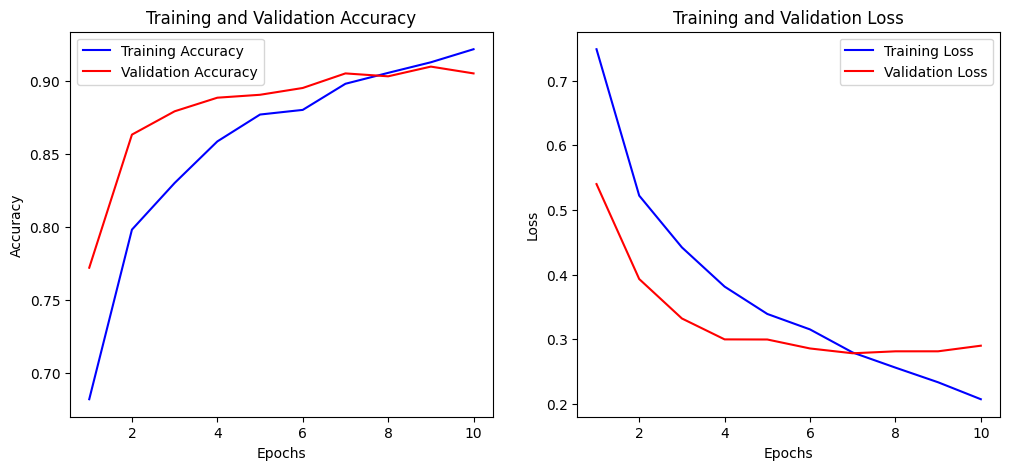

Model: "sequential_36"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_50 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_86 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,739 (2.57 MB)

 Trainable params: 224,579 (877.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 449,160 (1.71 MB)

In [37]:

import tensorflow as tf
from tensorflow.keras import layers, models

# --- Data ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test  = (y_test  < 3).flatten()
x_train = x_train[mask_train].astype("float32")/255.0
y_train = y_train[mask_train].flatten()
x_test  = x_test[mask_test].astype("float32")/255.0
y_test  = y_test[mask_test].flatten()

# --- Very small CNN model ---
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)), # filter size 3*3
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    layers.Dense(3, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3,          # if val_loss does not decrease after 3 epoch, then stop.
    restore_best_weights=True
)
# --- Train ---
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64, #The machine extracts the next 64 plates until the entire dataset is end.
    validation_split=0.1,
    verbose=1,
    callbacks=[early_stopping]
)

# Sau khi model.fit xong, hãy in dòng này ra:
print(history.history.keys())

# --- Evaluate ---
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)


def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 1.Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2.Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# call the func, after run model.fit()
plot_history(history)

model.summary()


# Multi-Layer Perceptron - MLP - Feedforward Neural Network

- The goal of this model is to classify small black and white images ($8 * 8$ pixels) into three different geometric groups.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

They are used to control randomness.

- np.random.seed(0): It's like random_state. use for Ensure that the data (vertical, horizontal, oblique images + noise) always forms a single, unique set. It locks in all the random steps in your data generation process. Specifically, the noise in image $8 \times 8$ and the shuffle order of the vertical, horizontal, and oblique images.

- tf.random.set_seed(0) (TensorFlow):
    - When you've just finished writing the code and haven't clicked the `model.fit` button (before training), the AI ​​brain is completely blank. However, to begin calculations, the neurons can't be empty; they need initial "draft" numbers.
    - It locks the Initial Weights values; these are the initial guessed numbers of the neurons before they begin learning.

    - And the result: Every time you run it, your AI starts from the exact same "starting point."

In [ ]:
# Simple 8x8 grayscale data

def make_sample(label, noise=0.05): #
    img = np.zeros((8, 8), dtype=np.float32) #Create an empty img frame (completely black, value 0).
    if label == 0:         # vertical bar
        img[:, 3] = 1.0    # chose 4th column
    elif label == 1:       # horizontal bar
        img[4, :] = 1.0 #chose 4th row
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32) 
        #The computer will randomly draw tiny numbers (like 0.01, -0.02) to add to each pixel. 
        # This is where np.random.seed(0) 
        # comes into play to ensure this "noise" is always the same every time it runs.
    return np.clip(img, 0.0, 1.0)

# The loop generates 600 data samples. 200 each
n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1), need to add 1 channel for grayscale
y = np.array(y, dtype=np.int32)    # (600,)

Instead of downloading images from the internet, Mira, or I, are creating artificial images to train the AI.


In [25]:
# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]
print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


The data is generated in the following order: 200 vertical images, then 200 horizontal images, and finally 200 diagonal images. If we feed this directly into AI, it will learn in that order (only seeing vertical lines, then only seeing horizontal lines), which makes the model easy to bias. SO, we need SHUFFLE.

Thanks for random seed at the beginning, this shuffle will the same.

and train is 80% which mean 480, and 120 for test.

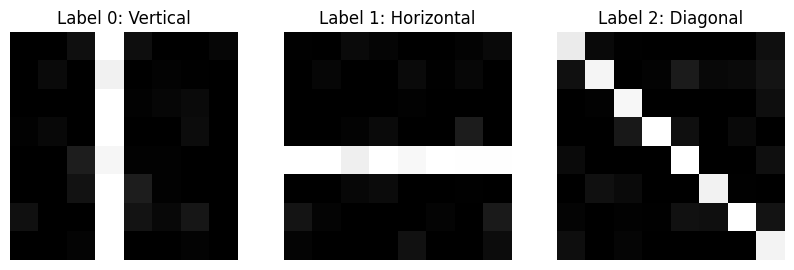

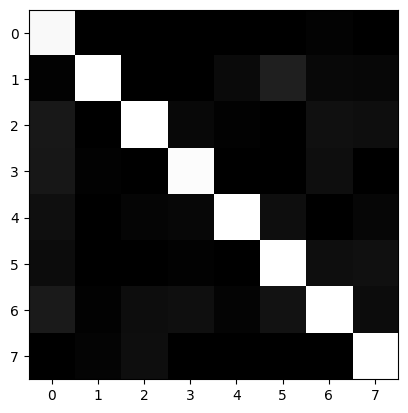

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


/Users/beam/2026_spring/IoT_Pipline_2026/ML/tf-env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6510 - loss: 0.9317 - val_accuracy: 0.6354 - val_loss: 0.8830
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.8351 - val_accuracy: 0.6354 - val_loss: 0.8000
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.7569 - val_accuracy: 0.6354 - val_loss: 0.7315
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.6890 - val_accuracy: 0.6354 - val_loss: 0.6697
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.6283 - val_accuracy: 0.6354 - val_loss: 0.6144
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.5743 - val_accuracy: 0.6354 - val_loss: 0.5648
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.5257 - val_accuracy: 0.6354 - val_loss: 0.5202
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6719 - loss: 0.4822 - val_accuracy: 0.6354 - val_loss: 0.4800

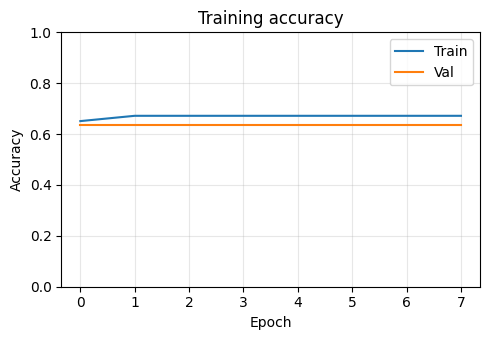

Test accuracy: 0.675


In [16]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

import random

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data

def make_sample(label, noise=0.05): #
    img = np.zeros((8, 8), dtype=np.float32) #Create an empty img frame (completely black, value 0).
    if label == 0:         # vertical bar
        img[:, 3] = 1.0    # chose 4th column
    elif label == 1:       # horizontal bar
        img[4, :] = 1.0 #chose 4th row
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32) 
        #The computer will randomly draw tiny numbers (like 0.01, -0.02) to add to each pixel. 
        # This is where np.random.seed(0) 
        # comes into play to ensure this "noise" is always the same every time it runs.
    return np.clip(img, 0.0, 1.0)

# The loop generates 600 data samples. 200 each
n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1), need to add 1 channel for grayscale
y = np.array(y, dtype=np.int32)    # (600,), change label into int


# Vẽ thử 3 loại hình ảnh: Đứng, Ngang, Xiên
plt.figure(figsize=(10, 3))

for i in range(3):
    plt.subplot(1, 3, i+1)
    # Tạo mẫu thử với nhãn i (0: dọc, 1: ngang, 2: xiên)
    sample_img = make_sample(i, noise=0.05) 
    
    plt.imshow(sample_img, cmap='gray')
    plt.title(f"Label {i}: " + ["Vertical", "Horizontal", "Diagonal"][i])
    plt.axis('off') # Ẩn trục tọa độ cho đẹp

plt.show()

# Chọn đại 1 tấm hình ngẫu nhiên từ tập X đã tạo
plt.imshow(X[random.randint(0, 599)], cmap='gray')
plt.show()

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Small MLP model
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — no params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy (train vs val)
plt.figure(figsize=(5,3.5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.title("Training accuracy")
plt.tight_layout()
plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
# from tensorflow.keras.utils import plot_model
# from IPython.display import Image, display
# plot_model(model, to_file="mlp_tiny.png")
# display(Image("mlp_tiny.png"))


# Functional API

This model still uses the same old dataset (8-pixel images with vertical, horizontal, and diagonal lines), but the difference lies in its brain structure. Instead of following a straight line (Sequential), this model uses a Functional API to create two parallel learning branches, allowing the model to learn different image features simultaneously.

In [4]:
# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input")
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0

# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260

# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="tiny_parallel_mlp")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()



Model: "tiny_parallel_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

1. Parallel Branch Architecture: 
- Imagine instead of just one person observing the image, you hire two people (Branch A and Branch B) to look at the image together. $8 \times 8$: 

- Common input: The image is flattened into 64 numbers using a Flatten layer. 

- Branch A (branch_a): A Dense layer with 4 neurons. This branch can focus on learning about angles.

- Branch B (branch_b): Another Dense layer also with 4 neurons. This branch can focus on learning about the position of bright pixels. 

- Concatenate: The results from the 4 neurons of branch A and 4 neurons of branch B are "pasted" together, forming a row of 8 values. Output: These 8 values ​​are fed into the final layer to make predictions about 3 labels (vertical, horizontal, oblique).

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)


Model: "tiny_parallel_mlp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 8, 8, 1)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 64)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchA_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branchB_dense       │ (None, 4)         │        260 │ flatten[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 8)         │          0 │ branchA_dense[0]… │
│ (Concatenate)       │                   │            │ branchB_dense[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         27 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 547 (2.14 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0000e+00 - loss: 1.2668 - val_accuracy: 0.0104 - val_loss: 1.1677
Epoch 2/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1849 - loss: 1.1077 - val_accuracy: 0.3229 - val_loss: 1.0259
Epoch 3/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5156 - loss: 0.9730 - val_accuracy: 0.7188 - val_loss: 0.9073
Epoch 4/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.8592 - val_accuracy: 1.0000 - val_loss: 0.8022
Epoch 5/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.7589 - val_accuracy: 1.0000 - val_loss: 0.7082
Epoch 6/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6711 - val_accuracy: 1.0000 - val_loss: 0.6256
Epoch 7/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.5924 - val_accuracy: 1.0000 - val_loss: 0.5502
Epoch 8/8
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.5202 - val_accuracy: 1.0000 - val_loss: 0.

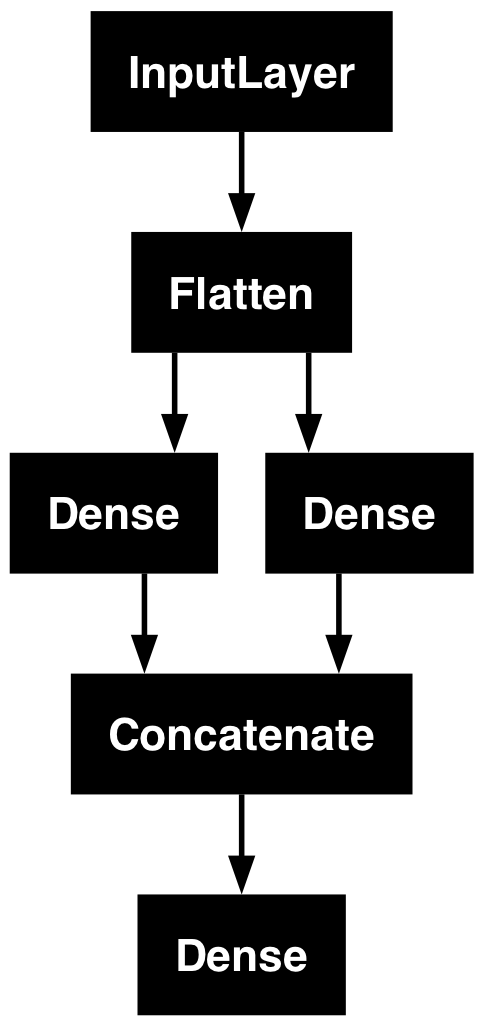

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


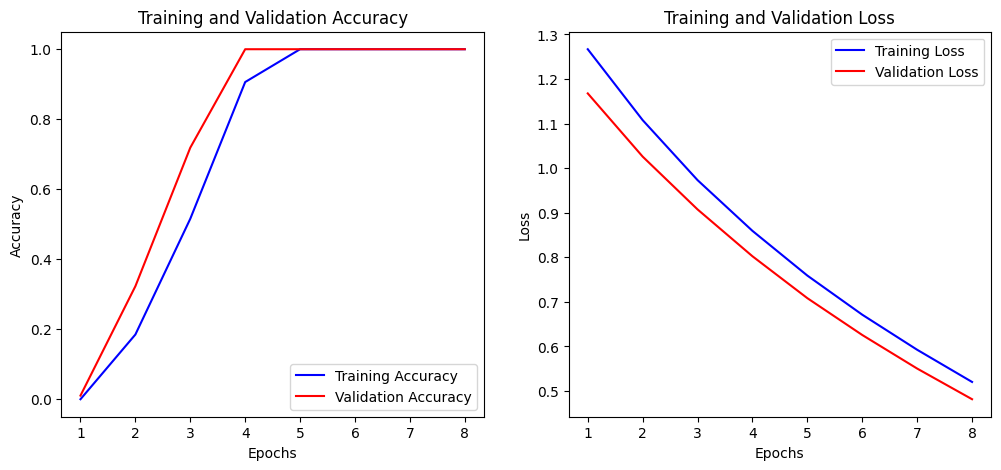

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Parallel-branches MLP (Functional API)
inputs = keras.Input(shape=(8, 8, 1), name="input")
x = layers.Flatten(name="flatten")(inputs)          # (None, 64) — params: 0

# Branch A: Dense(4)
branch_a = layers.Dense(4, activation="relu", name="branchA_dense")(x)  # params: 64*4 + 4 = 260

# Branch B: Dense(4)
branch_b = layers.Dense(4, activation="relu", name="branchB_dense")(x)  # params: 64*4 + 4 = 260

# Merge (concatenate)
merged = layers.Concatenate(name="concat")([branch_a, branch_b])

# Output: Dense(3)
outputs = layers.Dense(3, activation="softmax", name="output")(merged)

model = keras.Model(inputs, outputs, name="tiny_parallel_mlp")

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

model.summary()

# Train
history = model.fit(
    x_train, y_train,
    epochs=8,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot accuracy
# plt.figure(figsize=(5,3.5))
# plt.plot(history.history["accuracy"], label="Train")
# plt.plot(history.history["val_accuracy"], label="Val")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.ylim(0, 1)
# plt.grid(alpha=0.3)
# plt.legend()
# plt.title("Training accuracy (parallel branches)")
# plt.tight_layout()
# plt.show()

# Evaluate on test set
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Plot the model diagram
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
plot_model(model, to_file="parallel_mlp.png")
display(Image("parallel_mlp.png"))

print(history.history.keys())
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # 1.Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # 2.Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)


model.save("parallel_model.keras")


# Save to a .keras file

1. What does `model.save()`  save?
- When running this command, it packages three things into the `.keras` file:
- Architecture: How the layers are connected (Flatten, Dense, etc.).
- Weights: The optimized "tuning" after learning (this is the most important thing). 
- Training configuration: What the Optimizer is, what the Loss function is (so you can continue training if you want). 

- It does NOT save the data $X, y$ because data is usually very large (potentially up to GB), while the model file is only a few MB.

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

np.random.seed(0)
tf.random.set_seed(0)

# Simple 8x8 grayscale data
def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:         # vertical bar
        img[:, 3] = 1.0
    elif label == 1:       # horizontal bar
        img[3, :] = 1.0
    else:                  # diagonal
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Shuffle + split
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# MLP model 
model = keras.Sequential([
    layers.Flatten(input_shape=(8, 8, 1)),  # (None, 64) — 0 params
    layers.Dense(8, activation="relu"),     # 64*8 + 8 = 520 params
    layers.Dense(3, activation="softmax")   # 8*3 + 3 = 27 params
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(
    x_train, y_train,
    epochs=6,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

# Save to a .keras file
save_path = "miras_model.keras"
model.save(save_path)
print("Saved model to:", os.path.abspath(save_path))

Train: (480, 8, 8, 1) (480,)
Test:  (120, 8, 8, 1) (120,)
Epoch 1/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1562 - loss: 1.2196 - val_accuracy: 0.3021 - val_loss: 1.1288
Epoch 2/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3307 - loss: 1.0408 - val_accuracy: 0.3021 - val_loss: 0.9637
Epoch 3/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3984 - loss: 0.8926 - val_accuracy: 0.6979 - val_loss: 0.8296
Epoch 4/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9062 - loss: 0.7719 - val_accuracy: 1.0000 - val_loss: 0.7181
Epoch 5/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.6662 - val_accuracy: 1.0000 - val_loss: 0.6181
Epoch 6/6
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.5727 - val_accuracy: 1.0000 - val_loss: 0.5321
Test accuracy: 1.000
Saved model to: /Users/beam/2026_spring/IoT_Pipline_2026/ML/miras_model.keras


In [29]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

# Recreate the same simple dataset
np.random.seed(0)
tf.random.set_seed(0)

def make_sample(label, noise=0.05):
    img = np.zeros((8, 8), dtype=np.float32)
    if label == 0:
        img[:, 3] = 1.0
    elif label == 1:
        img[3, :] = 1.0
    else:
        np.fill_diagonal(img, 1.0)
    if noise:
        img += np.random.normal(0.0, noise, img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

n_per_class = 200
X, y = [], []
for c in range(3):
    for _ in range(n_per_class):
        X.append(make_sample(c))
        y.append(c)

X = np.array(X)[..., np.newaxis]   # (600, 8, 8, 1)
y = np.array(y, dtype=np.int32)    # (600,)

# Same split as before
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
split = int(0.8 * len(X))
x_train, y_train = X[:split], y[:split]
x_test,  y_test  = X[split:], y[split:]

# Load the saved .keras file
loaded_model = keras.models.load_model("miras_model.keras")
loaded_model.summary()

# Evaluate the loaded model
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Loaded model - test accuracy: {acc:.3f}")

# Predict a few samples
probs = loaded_model.predict(x_test[:5], verbose=0)  # shape: (5, 3)
preds = probs.argmax(axis=1)
print("Predictions:", preds)
print("True labels:", y_test[:5].tolist())

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,643 (6.42 KB)

 Trainable params: 547 (2.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,096 (4.29 KB)

Loaded model - test accuracy: 1.000
Predictions: [2 1 0 2 2]
True labels: [2, 1, 0, 2, 2]


In [13]:
import sys
print(sys.executable)

/Users/beam/2026_spring/IoT_Pipline_2026/ML/tf-env/bin/python
